# SPR-03 — Model Training + Ensembling

**Ticket:** SPR-03
**Owner:** Sakhiur
**Depends on:** SPR-02 (resampled train set)
**Folder:** `notebooks/04_modeling/02_ensembling.ipynb`
**Output:** trained models saved to `models/{decision_tree,logistic_regression,random_forest,xgboost}/`, metrics logged to `results/tables/`


## 1. Load resampled train set from SPR-02

In [ ]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_train_resampled_Sakhiur.csv

--2026-08-26 22:51:29--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_train_resampled_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.171.171.65, 3.171.171.6, 3.171.171.104, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.65|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6a7c7183f2c81824bdfb6fa9/9f6172a1773ccf26810ab1921082ea2b55dd1e0849d93107fe3e14ac836e8fd0?X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27X_train_resampled_Sakhiur.csv%3B+filename%3D%22X_train_resampled_Sakhiur.csv%22%3B&response-content-type=text%2Fcsv&user_id=public&Expires=1787788289&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmE3YzcxODNmMmM4MTgyNGJkZmI2ZmE5LzlmNjE3MmExNzczY2NmMjY4MTBhYjE5MjEwODJlYTJiNTVkZDFlMDg0OWQ5MzEwN2ZlM2UxNGFjODM2ZThmZDBcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomcmVzcG9

In [ ]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_test_Sakhiur.csv

--2026-08-26 22:51:31--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_test_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.171.171.65, 3.171.171.128, 3.171.171.6, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.65|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/X_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2FX_test_Sakhiur.csv=&etag=%2249ac492745f5c946abd59d29947ad5baa2a6d39d%22 [following]
--2026-08-26 22:51:31--  https://huggingface.co/api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/X_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2FX_test_Sakhiur.csv=&etag=%2249ac492745f5c946abd59d29947ad5baa2a6d39d%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 10184720 (9.7M) [text/plain]
Saving to:

In [ ]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_train_resampled_Sakhiur.csv

--2026-08-26 22:51:31--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_train_resampled_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.166.152.105, 3.166.152.65, 3.166.152.44, ...
Connecting to huggingface.co (huggingface.co)|3.166.152.105|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_train_resampled_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_train_resampled_Sakhiur.csv=&etag=%22d1dadfe2ca86451459223e55ad3fb4a057c0f083%22 [following]
--2026-08-26 22:51:31--  https://huggingface.co/api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_train_resampled_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_train_resampled_Sakhiur.csv=&etag=%22d1dadfe2ca86451459223e55ad3fb4a057c0f083%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response.

In [ ]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_test_Sakhiur.csv

--2026-08-26 22:51:31--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_test_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.171.171.104, 3.171.171.128, 3.171.171.6, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.104|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_test_Sakhiur.csv=&etag=%2265b12cabc0360608ebbdad6a81d0164f0522455e%22 [following]
--2026-08-26 22:51:31--  https://huggingface.co/api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_test_Sakhiur.csv=&etag=%2265b12cabc0360608ebbdad6a81d0164f0522455e%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 1199517 (1.1M) [text/plain]
Saving to

In [ ]:
import pandas as pd
import numpy as np
import random
import joblib
import os

np.random.seed(42)
random.seed(42)

X_train = pd.read_csv('X_train_resampled_Sakhiur.csv')
y_train = pd.read_csv('y_train_resampled_Sakhiur.csv').iloc[:, 0]
X_test = pd.read_csv('X_test_Sakhiur.csv')
y_test = pd.read_csv('y_test_Sakhiur.csv').iloc[:, 0]

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1049480, 25) Test: (150325, 25)


In [ ]:
!pip install catboost lightgbm -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


## 1b. Encode target labels
XGBoost requires integer class labels (0,1,2,...), not strings. This encodes `y_train`/`y_test` once here, and every downstream cell decodes predictions back to real class names before printing or plotting.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print('Class mapping:')
for i, label in enumerate(label_encoder.classes_):
    print(f'  {i} -> {label}')

Class mapping:
  0 -> Lower
  1 -> Middle
  2 -> No_income
  3 -> Upper


## 2. Hyperparameter search space
Same structure as `SOTA_Paper_8.ipynb` cell 39, trimmed to the four models your project actually uses (decision tree, RF, XGBoost, logistic regression) and depth-capped to stay inside Colab free-tier limits, per the compute constraint already flagged for this project.

In [ ]:
param_distributions = {
    'DecisionTreeClassifier': {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'RandomForestClassifier': {
        'n_estimators': [100, 150, 200],
        'max_depth': [10],  # capped per project compute constraint, do not widen
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBClassifier': {
        'n_estimators': [100, 150, 200],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    'LogisticRegression': {
        'C': [0.01, 0.1, 1.0, 10.0],
        'max_iter': [1000]
    },
    'CatBoostClassifier': {
        'iterations': [200, 400, 600],
        'depth': [6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [3, 5, 7]
    },
    'LGBMClassifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 70]
    },
}

## 3. Randomized search per model

## 3b. Manual resume: paste known best params to skip search
If Colab disconnects mid-search, or you already found good params in a previous run, paste them into `KNOWN_BEST_PARAMS` below. Any model listed here skips `RandomizedSearchCV` entirely and is just fit directly. Any model NOT listed here still goes through the normal search in the next cell.

Leave a model's entry out (or set the whole dict empty) to search everything from scratch.

In [ ]:
# Fill in only the models you already have good params for. Leave others out entirely,
# they'll be searched normally below.

KNOWN_BEST_PARAMS = {
     'DecisionTreeClassifier': {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20},
     'RandomForestClassifier': {'n_estimators': 100, 'min_samples_split': 10,
                                 'min_samples_leaf': 4, 'max_depth': 10},
     'CatBoostClassifier': {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 10},
     'XGBClassifier': {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05},
     'LogisticRegression': {'max_iter': 1000, 'C': 10.0},
      'LGBMClassifier': {'num_leaves': 50, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}
}

if KNOWN_BEST_PARAMS:
    print('Will skip search for:', list(KNOWN_BEST_PARAMS.keys()))
else:
    print('No manual params provided, everything below will be searched fresh.')

Will skip search for: ['DecisionTreeClassifier', 'RandomForestClassifier', 'CatBoostClassifier', 'XGBClassifier', 'LogisticRegression', 'LGBMClassifier']


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

base_models = {
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LogisticRegression': LogisticRegression(random_state=42),
    'CatBoostClassifier': CatBoostClassifier(random_seed=42, loss_function='MultiClass', verbose=0),
    'LGBMClassifier': LGBMClassifier(random_state=42, objective='multiclass', verbose=-1),

}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_params = {}
best_estimators = {}

model_classes = {
    'DecisionTreeClassifier': DecisionTreeClassifier,
    'RandomForestClassifier': RandomForestClassifier,
    'XGBClassifier': XGBClassifier,
    'LogisticRegression': LogisticRegression,
    'CatBoostClassifier': CatBoostClassifier,
    'LGBMClassifier': LGBMClassifier
}
model_fixed_kwargs = {
    'DecisionTreeClassifier': {'random_state': 42},
    'RandomForestClassifier': {'random_state': 42},
    'XGBClassifier': {'random_state': 42, 'eval_metric': 'mlogloss'},
    'LogisticRegression': {'random_state': 42},
    'CatBoostClassifier': {'random_seed': 42, 'loss_function': 'MultiClass', 'verbose': 0},
    'LGBMClassifier': {'random_state': 42, 'objective': 'multiclass', 'verbose': -1}
}

for name, model in base_models.items():
    if name in KNOWN_BEST_PARAMS:
        print(f'Skipping search for {name}, using provided params...')
        params = KNOWN_BEST_PARAMS[name]
        fitted = model_classes[name](**params, **model_fixed_kwargs[name])
        fitted.fit(X_train, y_train_enc)
        best_params[name] = params
        best_estimators[name] = fitted
        print(f'  Used params: {params}')
        continue

    print(f'Searching {name}...')
    search = RandomizedSearchCV(
        model, param_distributions[name],
        n_iter=10, cv=cv, scoring='f1_macro',
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train_enc)
    best_params[name] = search.best_params_
    best_estimators[name] = search.best_estimator_
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV macro F1: {search.best_score_:.4f}')

Skipping search for DecisionTreeClassifier, using provided params...
  Used params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
Skipping search for RandomForestClassifier, using provided params...
  Used params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Skipping search for XGBClassifier, using provided params...
  Used params: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05}
Skipping search for LogisticRegression, using provided params...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Used params: {'max_iter': 1000, 'C': 10.0}
Skipping search for CatBoostClassifier, using provided params...
  Used params: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 10}
Skipping search for LGBMClassifier, using provided params...
  Used params: {'num_leaves': 50, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}


## 4. Evaluate each tuned model on the held-out test set

--- DecisionTreeClassifier ---
              precision    recall  f1-score   support

       Lower      0.597     0.686     0.638     47885
      Middle      0.596     0.609     0.603     35182
   No_income      0.950     0.834     0.889     65593
       Upper      0.162     0.179     0.170      1665

    accuracy                          0.727    150325
   macro avg      0.576     0.577     0.575    150325
weighted avg      0.746     0.727     0.734    150325



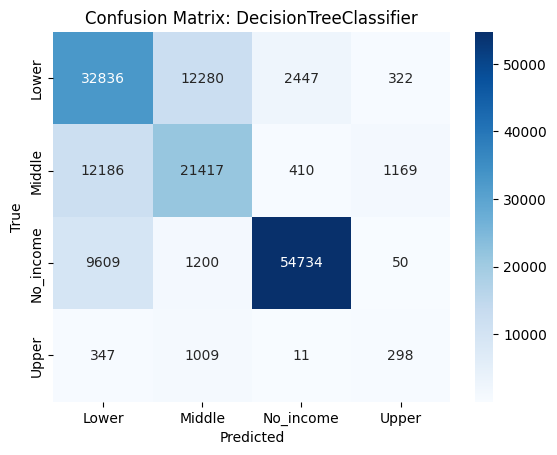

--- RandomForestClassifier ---
              precision    recall  f1-score   support

       Lower      0.598     0.701     0.646     47885
      Middle      0.583     0.571     0.577     35182
   No_income      0.992     0.797     0.884     65593
       Upper      0.101     0.427     0.163      1665

    accuracy                          0.710    150325
   macro avg      0.569     0.624     0.567    150325
weighted avg      0.761     0.710     0.728    150325



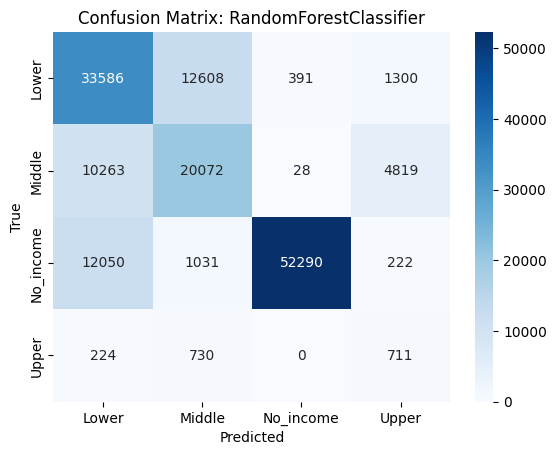

--- XGBClassifier ---
              precision    recall  f1-score   support

       Lower      0.616     0.720     0.664     47885
      Middle      0.625     0.649     0.637     35182
   No_income      0.970     0.831     0.895     65593
       Upper      0.198     0.186     0.191      1665

    accuracy                          0.746    150325
   macro avg      0.602     0.597     0.597    150325
weighted avg      0.768     0.746     0.753    150325



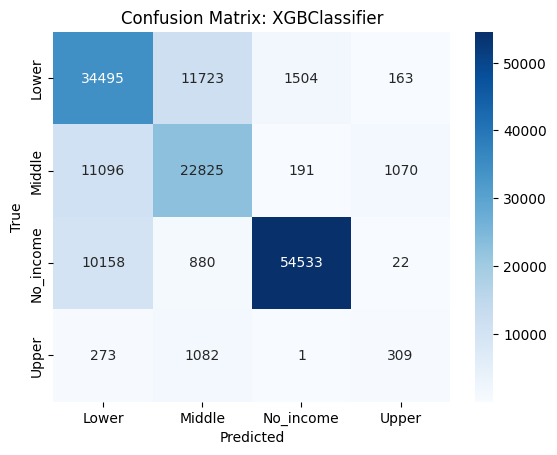

--- LogisticRegression ---
              precision    recall  f1-score   support

       Lower      0.594     0.684     0.636     47885
      Middle      0.569     0.542     0.555     35182
   No_income      0.966     0.817     0.885     65593
       Upper      0.114     0.421     0.180      1665

    accuracy                          0.706    150325
   macro avg      0.561     0.616     0.564    150325
weighted avg      0.745     0.706     0.721    150325



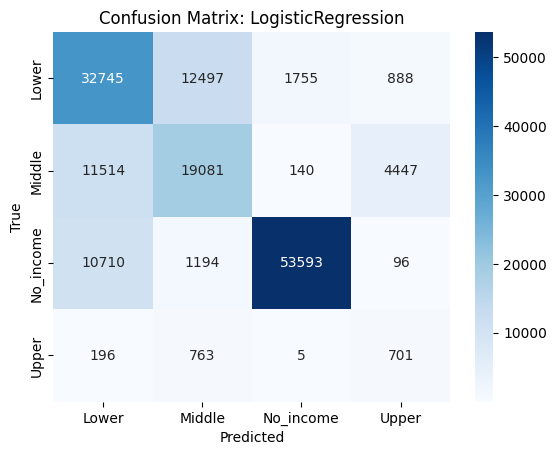

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


--- CatBoostClassifier ---
              precision    recall  f1-score   support

       Lower      0.617     0.716     0.663     47885
      Middle      0.623     0.649     0.636     35182
   No_income      0.969     0.833     0.896     65593
       Upper      0.197     0.206     0.201      1665

    accuracy                          0.746    150325
   macro avg      0.602     0.601     0.599    150325
weighted avg      0.768     0.746     0.753    150325



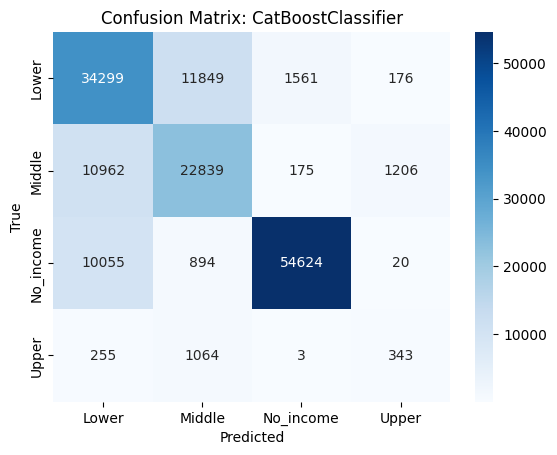

--- LGBMClassifier ---
              precision    recall  f1-score   support

       Lower      0.618     0.721     0.666     47885
      Middle      0.631     0.648     0.640     35182
   No_income      0.963     0.840     0.897     65593
       Upper      0.222     0.145     0.176      1665

    accuracy                          0.750    150325
   macro avg      0.608     0.589     0.595    150325
weighted avg      0.767     0.750     0.755    150325



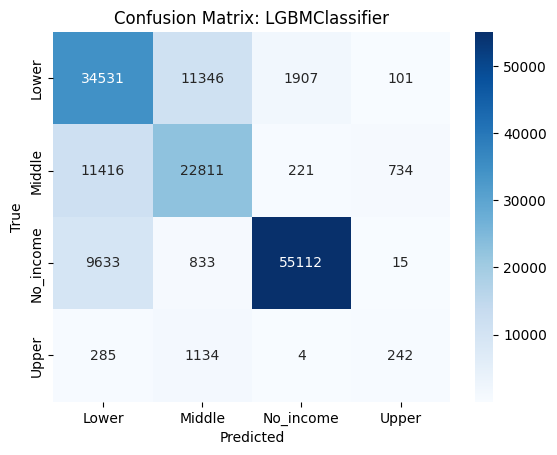

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

test_results = {}
for name, model in best_estimators.items():
    y_pred_enc = model.predict(X_test)
    y_pred = label_encoder.inverse_transform(y_pred_enc)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    test_results[name] = macro_f1
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, digits=3))
    cm = confusion_matrix(y_test, y_pred, labels=label_encoder.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.savefig(f"confusion_matrix_{name}.png", dpi=200, bbox_inches='tight')
    plt.show()

## 5. Select top 3 models by macro F1
Ranks all six single models (including LightGBM, now fixed) by their test macro F1 from Section 4, and picks the top 3 for both hard and soft voting. This is computed dynamically from `test_results`, not hardcoded, so it stays correct even if LightGBM's actual score changes which models rank in the top 3.

In [ ]:
top_3_names = sorted(test_results, key=test_results.get, reverse=True)[:3]
print(f'Top 3 models by test macro F1:')
for name in top_3_names:
    print(f'  {name}: {test_results[name]:.4f}')

top_3_estimators = [(name, best_estimators[name]) for name in top_3_names]

## 6. Ensembling: hard + soft voting on top 3 models

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
import numpy as np

class FlattenPredict(ClassifierMixin, BaseEstimator):
    """Wrapper that forces CatBoost.predict() to return a 1-D array."""
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y, **fit_params):
        self.estimator_ = clone(self.estimator).fit(X, y, **fit_params)
        self.classes_ = self.estimator_.classes_
        self.n_features_in_ = getattr(self.estimator_, "n_features_in_", None)
        if hasattr(self.estimator_, "feature_names_in_"):
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self

    def predict(self, X):
        return np.asarray(self.estimator_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)

In [ ]:
from sklearn.ensemble import VotingClassifier

top_3_estimators = []
for name in top_3_names:
    est = best_estimators[name]
    if "CatBoost" in name:                 # safer check
        est = FlattenPredict(est)
    top_3_estimators.append((name, est))

voting_clf_hard = VotingClassifier(
    estimators=top_3_estimators, voting="hard", n_jobs=-1
)
voting_clf_soft = VotingClassifier(
    estimators=top_3_estimators, voting="soft", n_jobs=-1
)

print("Training hard voting...")
voting_clf_hard.fit(X_train, y_train_enc)
print("Training soft voting...")
voting_clf_soft.fit(X_train, y_train_enc)

Training hard voting...
Training soft voting...


VotingClassifier(estimators=[('CatBoostClassifier',
                              FlattenPredict(estimator=CatBoostClassifier(depth=10, iterations=400, l2_leaf_reg=7, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0))),
                             ('XGBClassifier',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, d...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('LGBMClassifier',
                              LGBMClassifier(max_depth=8, n_estimators=300,
                                             num_leaves=50,
                                             objective='multiclass',
                                             random_state=42, verbose=-1))],
                 n_jobs=-1, voting='soft')

In [ ]:
print("Hard voting predictors:")
for est in voting_clf_hard.estimators_:
    pred = est.predict(X_test)
    print(type(est).__name__, pred.shape, pred.dtype)

print("\nSoft voting predict_proba:")
for est in voting_clf_soft.estimators_:
    proba = est.predict_proba(X_test)
    print(type(est).__name__, proba.shape)

Hard voting predictors:
FlattenPredict (150325,) int64
XGBClassifier (150325,) int64
LGBMClassifier (150325,) int64

Soft voting predict_proba:
FlattenPredict (150325, 4)
XGBClassifier (150325, 4)
LGBMClassifier (150325, 4)


## 7. Evaluate top-3 ensembles

--- Ensemble Model (Hard Voting, Top 3) ---
              precision    recall  f1-score   support

       Lower      0.617     0.723     0.666     47885
      Middle      0.628     0.648     0.638     35182
   No_income      0.969     0.834     0.896     65593
       Upper      0.205     0.177     0.190      1665

    accuracy                          0.748    150325
   macro avg      0.605     0.596     0.597    150325
weighted avg      0.769     0.748     0.755    150325



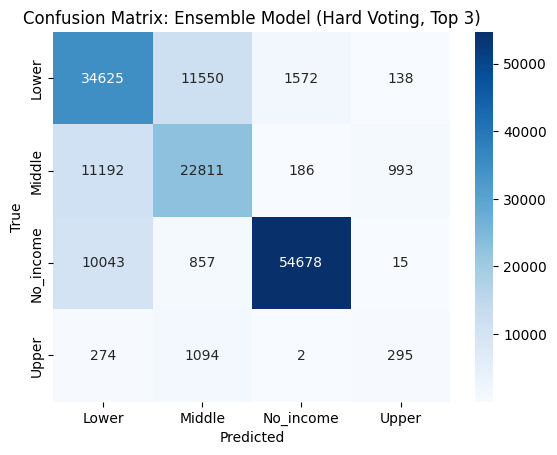

--- Ensemble Model (Soft Voting, Top 3) ---
              precision    recall  f1-score   support

       Lower      0.617     0.722     0.666     47885
      Middle      0.628     0.650     0.639     35182
   No_income      0.969     0.834     0.896     65593
       Upper      0.212     0.176     0.192      1665

    accuracy                          0.748    150325
   macro avg      0.607     0.596     0.598    150325
weighted avg      0.769     0.748     0.755    150325



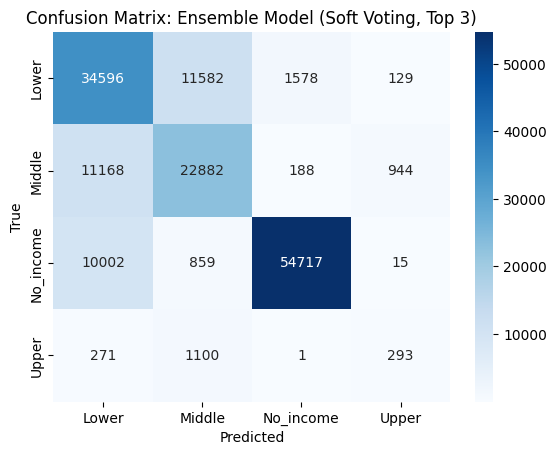

In [ ]:
for clf, label in zip([voting_clf_hard, voting_clf_soft],
                      ['Ensemble Model (Hard Voting, Top 3)', 'Ensemble Model (Soft Voting, Top 3)']):
    y_pred_enc = clf.predict(X_test)
    y_pred = label_encoder.inverse_transform(y_pred_enc)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    test_results[label] = macro_f1
    print(f'--- {label} ---')
    print(classification_report(y_test, y_pred, digits=3))
    cm = confusion_matrix(y_test, y_pred, labels=label_encoder.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {label}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.savefig(f"confusion_matrix_{label.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')}.png", dpi=200, bbox_inches='tight')
    plt.show()

## 8. comparison table
Matches the reference table format (Accuracy / F1-Score / Precision / Recall / ROC-AUC, all in %). Standard deviation is intentionally omitted here due to compute constraints on this dataset scale; see Methodology for the disclosure statement explaining this choice. All metrics are single-split test-set results, not cross-validated.

--- LGBMClassifier ---
              precision    recall  f1-score   support

       Lower      0.618     0.721     0.666     47885
      Middle      0.631     0.648     0.640     35182
   No_income      0.963     0.840     0.897     65593
       Upper      0.222     0.145     0.176      1665

    accuracy                          0.750    150325
   macro avg      0.608     0.589     0.595    150325
weighted avg      0.767     0.750     0.755    150325



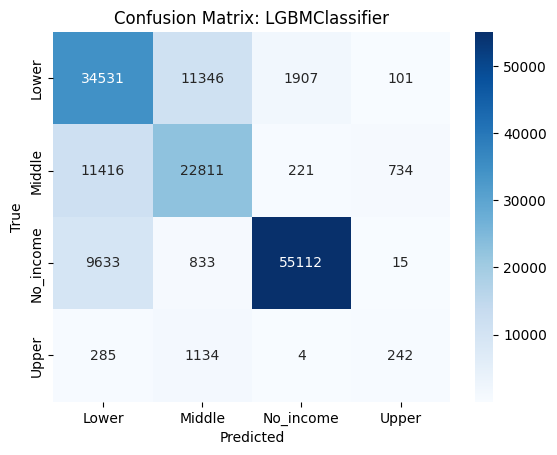

                       Model Accuracy(%) F1-Score(%) Precision(%) Recall(%) ROC-AUC(%)
      DecisionTreeClassifier       72.70       57.49        57.65     57.70      84.30
      RandomForestClassifier       70.95       56.74        56.85     62.40      89.45
               XGBClassifier       74.61       59.68        60.21     59.65      90.67
          LogisticRegression       70.59       56.40        56.07     61.61      88.85
          CatBoostClassifier       74.58       59.90        60.15     60.11      90.81
              LGBMClassifier       74.97       59.46        60.85     58.88      90.72
Ensemble Model (Hard Voting)       74.78       59.75        60.46     59.56        N/A
Ensemble Model (Soft Voting)       74.83       59.84        60.66     59.58      90.87


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

lgbm = best_estimators['LGBMClassifier']

# call the REAL methods, ignore any monkey-patch
y_pred_enc = LGBMClassifier.predict(lgbm, X_test)
y_proba = LGBMClassifier.predict_proba(lgbm, X_test)
y_pred = label_encoder.inverse_transform(np.asarray(y_pred_enc).ravel())

# --- confusion matrix ---
print('--- LGBMClassifier ---')
print(classification_report(y_test, y_pred, digits=3))
cm = confusion_matrix(y_test, y_pred, labels=label_encoder.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix: LGBMClassifier')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

# --- summary table (all models; LGBM uses unbound methods) ---
all_models = dict(best_estimators)
all_models['Ensemble Model (Hard Voting)'] = voting_clf_hard
all_models['Ensemble Model (Soft Voting)'] = voting_clf_soft

table_rows = []
for name, model in all_models.items():
    try:
        if isinstance(model, LGBMClassifier):
            pred_enc = LGBMClassifier.predict(model, X_test)
            proba = LGBMClassifier.predict_proba(model, X_test)
        else:
            pred_enc = np.asarray(model.predict(X_test)).ravel()
            proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
            # soft voting may contain patched LGBM — try; if fails, ROC = N/A
    except TypeError:
        pred_enc = np.asarray(model.predict(X_test)).ravel()
        proba = None

    pred = label_encoder.inverse_transform(pred_enc)
    acc = accuracy_score(y_test, pred) * 100
    f1 = f1_score(y_test, pred, average='macro') * 100
    prec = precision_score(y_test, pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, pred, average='macro', zero_division=0) * 100

    if proba is not None:
        try:
            roc = roc_auc_score(y_test_enc, proba, average='macro', multi_class='ovr') * 100
            roc_str = f'{roc:.2f}'
        except Exception:
            roc_str = 'N/A'
    else:
        roc_str = 'N/A'

    table_rows.append({
        'Model': name,
        'Accuracy(%)': f'{acc:.2f}',
        'F1-Score(%)': f'{f1:.2f}',
        'Precision(%)': f'{prec:.2f}',
        'Recall(%)': f'{rec:.2f}',
        'ROC-AUC(%)': roc_str
    })

comparison_table = pd.DataFrame(table_rows)
print(comparison_table.to_string(index=False))

## 9. Save all models, confusion matrices, and comparison table

In [ ]:
os.makedirs('models/decision_tree', exist_ok=True)
os.makedirs('models/random_forest', exist_ok=True)
os.makedirs('models/xgboost', exist_ok=True)
os.makedirs('models/logistic_regression', exist_ok=True)
os.makedirs('models/catboost', exist_ok=True)
os.makedirs('models/lightgbm', exist_ok=True)
os.makedirs('models/voting_ensemble', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

joblib.dump(best_estimators['DecisionTreeClassifier'], 'models/decision_tree/model.joblib')
joblib.dump(best_estimators['RandomForestClassifier'], 'models/random_forest/model.joblib')
joblib.dump(best_estimators['XGBClassifier'], 'models/xgboost/model.joblib')
joblib.dump(best_estimators['LogisticRegression'], 'models/logistic_regression/model.joblib')
joblib.dump(best_estimators['CatBoostClassifier'], 'models/catboost/model.joblib')
joblib.dump(best_estimators['LGBMClassifier'], 'models/lightgbm/model.joblib')
joblib.dump(voting_clf_hard, 'models/voting_ensemble/hard_voting_top3.joblib')
joblib.dump(voting_clf_soft, 'models/voting_ensemble/soft_voting_top3.joblib')
joblib.dump(label_encoder, 'models/label_encoder.joblib')
joblib.dump(top_3_names, 'models/voting_ensemble/top3_model_names.joblib')

comparison_table.to_csv('results/tables/model_comparison_plos_format.csv', index=False)

results_df = pd.DataFrame(list(test_results.items()), columns=['model', 'macro_f1'])
results_df = results_df.sort_values('macro_f1', ascending=False)
results_df.to_csv('results/tables/model_comparison.csv', index=False)

print('Saved all models to models/, comparison table to results/tables/model_comparison_plos_format.csv')
print()
print(results_df)
print()
print('Best single model for SPR-05 SHAP analysis:', results_df.iloc[0]['model'])

Saved all models to models/, comparison table to results/tables/model_comparison_plos_format.csv

                                 model  macro_f1
4                   CatBoostClassifier  0.598993
7  Ensemble Model (Soft Voting, Top 3)  0.598436
6  Ensemble Model (Hard Voting, Top 3)  0.597489
2                        XGBClassifier  0.596848
5                       LGBMClassifier  0.594584
0               DecisionTreeClassifier  0.574914
1               RandomForestClassifier  0.567391
3                   LogisticRegression  0.563971

Best single model for SPR-05 SHAP analysis: CatBoostClassifier


In [ ]:
!zip -r models_and_results.zip models results

updating: models/ (stored 0%)
updating: models/catboost/ (stored 0%)
updating: models/catboost/model.joblib (deflated 81%)
updating: models/logistic_regression/ (stored 0%)
updating: models/logistic_regression/model.joblib (deflated 26%)
updating: models/voting_ensemble/ (stored 0%)
updating: models/voting_ensemble/top3_model_names.joblib (deflated 31%)
updating: models/decision_tree/ (stored 0%)
updating: models/decision_tree/model.joblib (deflated 81%)
updating: models/xgboost/ (stored 0%)
updating: models/lightgbm/ (stored 0%)
updating: models/lightgbm/model.joblib (deflated 58%)
updating: models/label_encoder.joblib (deflated 34%)
updating: models/random_forest/ (stored 0%)
updating: models/random_forest/model.joblib (deflated 59%)
updating: results/ (stored 0%)
updating: results/tables/ (stored 0%)
updating: results/tables/model_comparison_plos_format.csv (deflated 40%)
updating: results/tables/model_comparison.csv (deflated 38%)
updating: results/figures/ (stored 0%)
  adding: mo